# Data Analysis: Trust
This script contains the data analysis for Trust.

### Content:
* Median and IQR per group
* Stacked percentage bar chart and interaction plot
* Aligned Rank Transform (ART) ANOVA
* Simple main effects analysis

In [ ]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 2.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import pingouin as pg
import scipy.stats as stats

# Load data (csv format)

file_path = "/content/results-filtered-94.csv" # Replace with your filename
df = pd.read_csv(file_path, sep=";")

print(f"Data shape: {df.shape[0]} rows, {df.shape[1]} columns\n")


Data shape: 94 rows, 80 columns



In [ ]:
# Removes the string descriptions in the data
df = df.replace("7 (strongly agree)", "7")
df = df.replace("1 (strongly disagree)", "1")

In [27]:
# Prepare independent variables for two-way ART ANOVA

language_mapping = {
    1: "Gender-Specific",
    2: "Gender-Neutral",
    3: "Gender-Specific",
    4: "Gender-Neutral"
}

style_mapping = {
    1: "Empathetic",
    2: "Empathetic",
    3: "Neutral",
    4: "Neutral"
}

df['Language'] = df['group'].map(language_mapping)
df['Style'] = df['group'].map(style_mapping)

print("Preview of decoded groups:")
print(df[['group', 'Language', 'Style']].drop_duplicates().to_string(index=False))


Preview of decoded groups:
 group        Language      Style
     3 Gender-Specific    Neutral
     2  Gender-Neutral Empathetic
     1 Gender-Specific Empathetic
     4  Gender-Neutral    Neutral


In [ ]:
# Define dimension item

dimension_items = ["PO2T[SQ017]"]

# Create a subset dataframe containing just this item
df_dim = df[dimension_items].dropna()

In [ ]:
# Median and IQR per group
print("--- Trust descriptives per group ---")

# Transform strings to numeric values
df["PO2T[SQ017]"] = pd.to_numeric(df["PO2T[SQ017]"], errors="coerce")

# Median per group
cell_medians = df.groupby(["group"])["PO2T[SQ017]"].median()
print("Medians:\n", cell_medians)


# IQR helper function
def calculate_iqr(series):
    return series.quantile(0.75) - series.quantile(0.25)

# IQR per group
cell_iqrs = df.groupby(["group"])[
    "PO2T[SQ017]"
].apply(calculate_iqr)
print("IQRs:\n", cell_iqrs)

--- Trust descriptives per group ---
Medians:
 group
1    4.0
2    2.0
3    3.0
4    3.0
Name: PO2T[SQ017], dtype: float64
IQRs:
 group
1    3.00
2    3.00
3    3.00
4    2.25
Name: PO2T[SQ017], dtype: float64


Stacked percentage bar chart

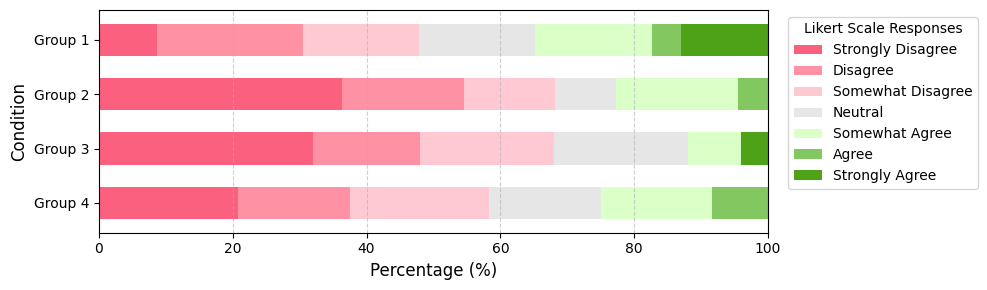

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dimensions = {
    "Trust": dimension_items
}

likert_labels = [
    "Strongly Disagree",
    "Disagree",
    "Somewhat Disagree",
    "Neutral",
    "Somewhat Agree",
    "Agree",
    "Strongly Agree",
]

# Aggregate raw responses into percentages
rows = []

# Loop through each group and dimensions
for group_num in sorted(df["group"].unique()):
    group_data = df[df["group"] == group_num]

    for dim_name, item_list in dimensions.items():
        # Flatten items for this dimension into a single row
        flat_responses = group_data[item_list].values.flatten()

        # Count frequencies of scores 1 through 7
        counts = pd.Series(flat_responses).value_counts()

        # Fill scores with 0 counts
        counts = counts.reindex(range(1, 8), fill_value=0)

        # Convert counts into percentages that sum up to 100%
        percentages = (counts / counts.sum()) * 100

        # Save row data labeled by group
        row_entry = {"Label": f"Group {group_num}"}
        for i, score_name in enumerate(likert_labels):
            row_entry[score_name] = percentages.iloc[i]

        rows.append(row_entry)

# Convert processed list into a plotting DataFrame
df_plot = pd.DataFrame(rows).set_index("Label")

likert_colors = [
    "#fb607f",  # Strongly Disagree (Deep Red)
    "#ff91a4",  # Disagree (Light Red)
    "#ffc9d3",  # Somewhat Disagree (Pink)
    "#e6e6e6",  # Neutral (Light Gray)
    "#daffc7",  # Somewhat Agree (Light Green)
    "#83c760",  # Agree (Medium Green)
    "#4ea217",  # Strongly Agree (Deep Green)
]

fig, ax = plt.subplots(figsize=(10, 3))

# Plot horizontal stacked bar chart
df_plot.plot(
    kind="barh", stacked=True, color=likert_colors, width=0.6, ax=ax
)

# Reverse the vertical axis layout so group 1 appears at the top
ax.invert_yaxis()

ax.set_xlabel("Percentage (%)", fontsize=12)
ax.set_ylabel("Condition", fontsize=12)
ax.set_xlim(0, 100)
ax.xaxis.grid(True, linestyle="--", alpha=0.6)

# Position the legend outside the chart on the right side
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Likert Scale Responses",
    frameon=True,
)

plt.tight_layout()
plt.show()

ART ANOVA

In [ ]:
%load_ext rpy2.ipython

In [ ]:
# Create a subset with only the 1 column needed for the test
df = df.rename(columns={"PO2T[SQ017]": "Trust_Score"})

df_clean = df[['Trust_Score', 'Language', 'Style']].dropna()

print(f"Data for R: {df_clean.shape[0]} rows and {df_clean.shape[1]} columns")

Data for R: 94 rows and 3 columns


In [ ]:
%%R -i df_clean
# Install ARTool, dplyr, and lme4 if not already installed
if (!require(ARTool)) {
  install.packages("ARTool")
  library(ARTool)
}
if (!require(dplyr)) {
  install.packages("dplyr")
  library(dplyr)
}
if (!require(lme4)) {
  install.packages("lme4")
  library(lme4)
}



Loading required package: ARTool
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘lme4’, ‘car’, ‘plyr’, ‘emmeans’

trying URL 'https://cran.rstudio.com/src/contrib/colorspace_2.1-3.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/fracdiff_1.5-4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/lmtest_0.9-40.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/timeDate_4052.112.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/urca_1.3-4.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/zoo_1.8-15.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/RcppArmadillo_15.4.0-1.tar.gz'


In [ ]:
%%R -i df_clean

df_clean$Language <- as.factor(df_clean$Language)
df_clean$Style    <- as.factor(df_clean$Style)

# Fit the Aligned Rank Transform model
# Format: Dependent_Variable ~ Factor1 * Factor2
art_model <- art(Trust_Score ~ Language * Style, data = df_clean)

art_anova <- anova(art_model)

# verbose=TRUE to print sums of squares
print(art_anova, verbose=TRUE)

# To get partial eta-squared
art_anova$eta.sq.part = with(art_anova, `Sum Sq`/(`Sum Sq` + `Sum Sq.res`))
art_anova


Analysis of Variance of Aligned Rank Transformed Data

Table Type: Anova Table (Type III tests) 
Model: No Repeated Measures (lm)
Response: art(Trust_Score)

                 Df Df.res  Sum Sq Sum Sq.res F value   Pr(>F)  
1 Language        1     90  635.98      67981 0.84197 0.361287  
2 Style           1     90  547.94      68237 0.72269 0.397518  
3 Language:Style  1     90 3970.48      64648 5.52754 0.020903 *
---
Signif. codes:   0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1 
Analysis of Variance of Aligned Rank Transformed Data

Table Type: Anova Table (Type III tests) 
Model: No Repeated Measures (lm)
Response: art(Trust_Score)

                 Df Df.res F value   Pr(>F) eta.sq.part  
1 Language        1     90 0.84197 0.361287   0.0092685  
2 Style           1     90 0.72269 0.397518   0.0079660  
3 Language:Style  1     90 5.52754 0.020903   0.0578633 *
---
Signif. codes:   0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1 


In [ ]:
%%R

# Simple main effects (better than Tukey)
interaction_lm <- artlm(art_model, "Language:Style")

install.packages("emmeans")
library(emmeans)

# Language | Style since Language is my primary variable
simple <- emmeans(interaction_lm, ~ Language | Style)
print(pairs(simple))

Style = Empathetic:
 contrast                             estimate   SE df t.ratio p.value
 (Gender-Neutral) - (Gender-Specific)    -14.1 7.99 90  -1.767  0.0806

Style = Neutral:
 contrast                             estimate   SE df t.ratio p.value
 (Gender-Neutral) - (Gender-Specific)     11.9 7.66 90   1.554  0.1237



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/emmeans_2.0.4.tar.gz'
Content type 'application/x-gzip' length 1763691 bytes (1.7 MB)
downloaded 1.7 MB


The downloaded source packages are in
	‘/tmp/RtmpPVqZ4R/downloaded_packages’


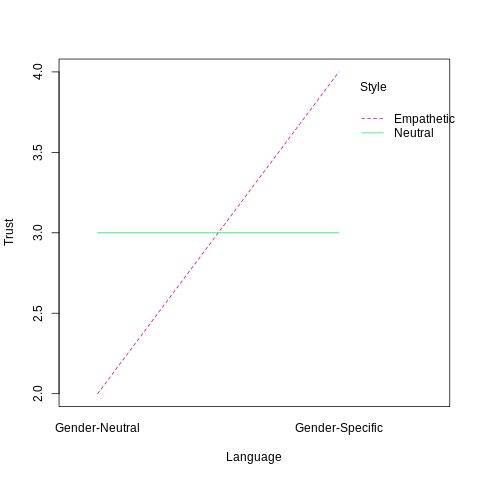

In [ ]:
%%R
# Interaction plot
interaction.plot(x.factor=df_clean$Language, trace.factor=df_clean$Style, response=df_clean$Trust_Score, fun=median, ylab="Trust", xlab="Language", trace.label="Style", col = c("#D701A5", "#02F34C"))
